In [ ]:
from google.colab import files
files.upload()  # Isso permitirá que você faça o upload do arquivo 'kaggle.json'

In [7]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/root/.kaggle'  # Define o diretório de configuração do Kaggle
os.makedirs('/root/.kaggle', exist_ok=True)  # Cria o diretório .kaggle se não existir
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')  # Renomeia e move o arquivo

In [11]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors


In [12]:
!unzip intel-image-classification.zip -d /content/dataset/

A saída de streaming foi truncada nas últimas 5000 linhas.
  inflating: /content/dataset/seg_train/seg_train/mountain/7506.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7537.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7539.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7551.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7560.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7565.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7578.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7581.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7586.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7647.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7652.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7654.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7662.jpg  
  inflating: /content/dataset/s

In [18]:
## 1. Environment Setup
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50

# Set random seeds for reproducibility  || great for making sure that the results are great
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ## 2. Data Loading and Exploration
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset paths
DATA_DIR = "dataset/seg_train/seg_train"
TEST_DIR = "dataset/seg_test/seg_test"

# Parameters
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
NUM_CLASSES = 6


In [14]:
# Create generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)


Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


Batch shape: (32, 150, 150, 3)


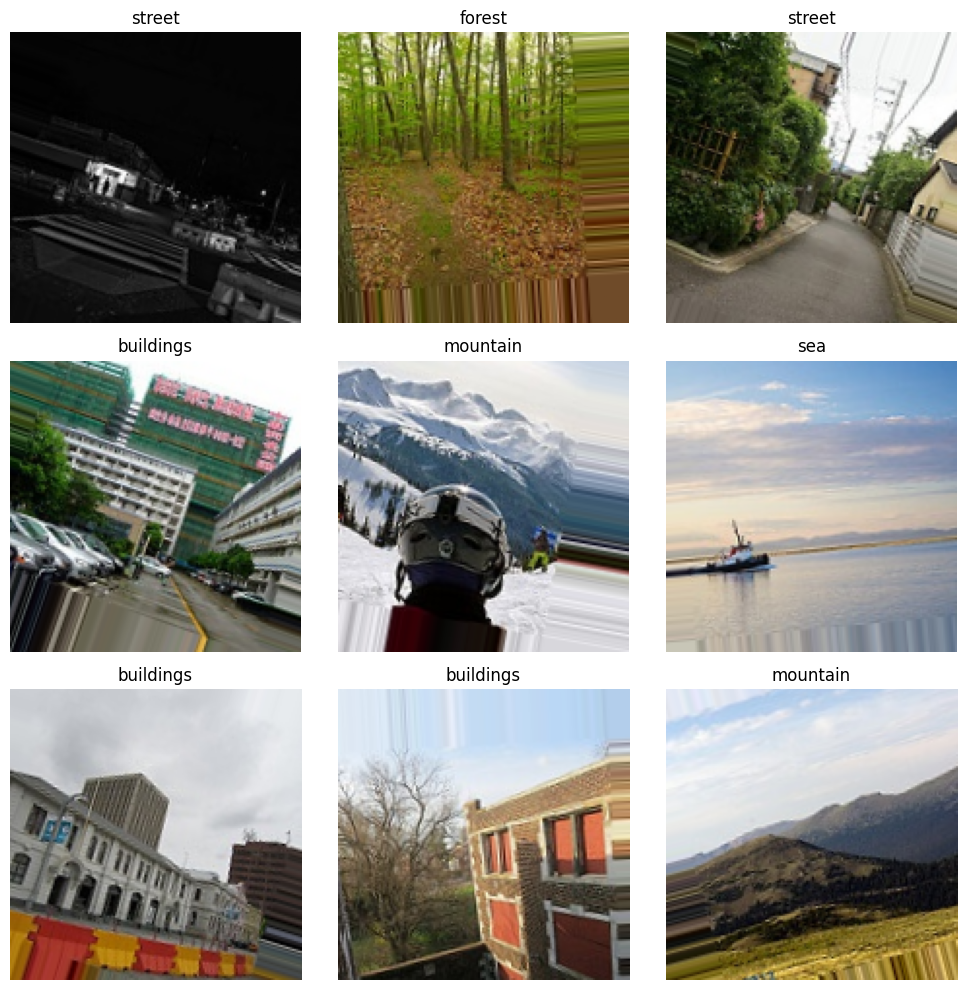

In [15]:
# ## 3. Data Visualization
class_names = list(train_generator.class_indices.keys())

# Verifica o número de imagens no batch
images, labels = next(train_generator)
print(f"Batch shape: {images.shape}")  # <-- ajuda a debugar

# Só mostra até no máximo o número de imagens disponíveis
n = min(9, len(images))

plt.figure(figsize=(10, 10))
for i in range(n):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [8]:
# 4. Transfer Learning with Fine-Tuning
def build_finetuned_model():
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = True  # Direct fine-tuning
    for layer in base_model.layers[:100]:
      layer.trainable = False
    inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = base_model(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs)

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_finetuned_model()
model.summary()

<ipython-input-8-99d818373463>:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │           3,078 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,916,934 (11.13 MB)

 Trainable params: 2,520,390 (9.61 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [ ]:
# 5. Train the fine-tuned model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    ]
)


Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 139s 340ms/step - accuracy: 0.3461 - loss: 1.6831 - val_accuracy: 0.7140 - val_loss: 0.7736
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 239ms/step - accuracy: 0.7164 - loss: 0.7751 - val_accuracy: 0.7942 - val_loss: 0.5347
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 239ms/step - accuracy: 0.7893 - loss: 0.5763 - val_accuracy: 0.8406 - val_loss: 0.4524
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 241ms/step - accuracy: 0.8214 - loss: 0.5079 - val_accuracy: 0.8502 - val_loss: 0.3939
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 85s 241ms/step - accuracy: 0.8333 - loss: 0.4696 - val_accuracy: 0.8673 - val_loss: 0.3584
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 240ms/step - accuracy: 0.8470 - loss: 0.4245 - val_accuracy: 0.8709 - val_loss: 0.3599
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 240ms/step - accuracy: 0.8591 - loss: 0.3948 - val_accuracy: 0.8787 - val_loss: 0.3311
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 87s 248ms/step - accuracy: 0.8554 - loss: 

In [ ]:
from tensorflow import keras

best_model = keras.models.load_model('best_model.h5')
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,                     # diretório com subpastas por classe
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',     # ou 'sparse' se tiveres labels como inteiros
    shuffle=False                 # importante para avaliação/matriz de confusão
)

Found 3000 images belonging to 6 classes.


In [ ]:
test_loss, test_acc = best_model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8804 - loss: 0.3518
Test accuracy: 0.8680 | Test loss: 0.3916


In [20]:
def build_resnet_model():
    # Carregar ResNet50 pré-treinada
    base_model = ResNet50(
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        include_top=False,
        weights='imagenet'
    )

    # Congelar as primeiras 100 camadas
    base_model.trainable = True  # Fine-tuning direto
    for layer in base_model.layers[:100]:
        layer.trainable = False

    # Construir modelo personalizado
    inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = base_model(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
    return model


resnet_model = build_resnet_model()
resnet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,639,878 (93.99 MB)

 Trainable params: 20,505,094 (78.22 MB)

 Non-trainable params: 4,134,784 (15.77 MB)

In [22]:
# 5. Train the fine-tuned model Resnet
history = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    ]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 154s 343ms/step - accuracy: 0.3640 - loss: 1.5149 - val_accuracy: 0.3755 - val_loss: 1.4674
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 99s 283ms/step - accuracy: 0.5664 - loss: 1.0952 - val_accuracy: 0.5788 - val_loss: 1.0174
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 100s 285ms/step - accuracy: 0.5984 - loss: 1.0162 - val_accuracy: 0.6134 - val_loss: 0.9875
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 99s 282ms/step - accuracy: 0.6270 - loss: 0.9416 - val_accuracy: 0.5927 - val_loss: 1.0392
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 104s 295ms/step - accuracy: 0.6485 - loss: 0.8943 - val_accuracy: 0.6273 - val_loss: 0.9121
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 100s 285ms/step - accuracy: 0.6571 - loss: 0.8796 - val_accuracy: 0.6109 - val_loss: 0.9620
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 101s 287ms/step - accuracy: 0.6697 - loss: 0.8672 - val_accuracy: 0.4886 - val_loss: 1.3316
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 99s 283ms/step - accuracy: 0.6692 - lo

<Axes: >

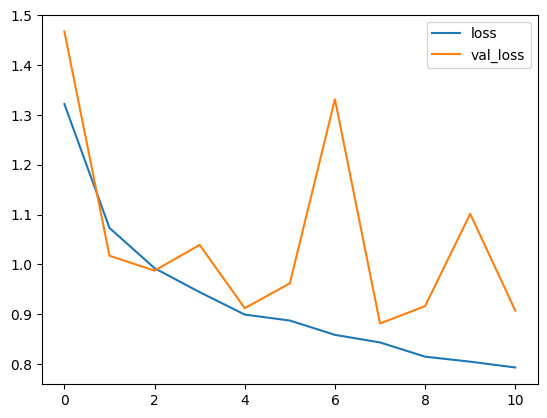

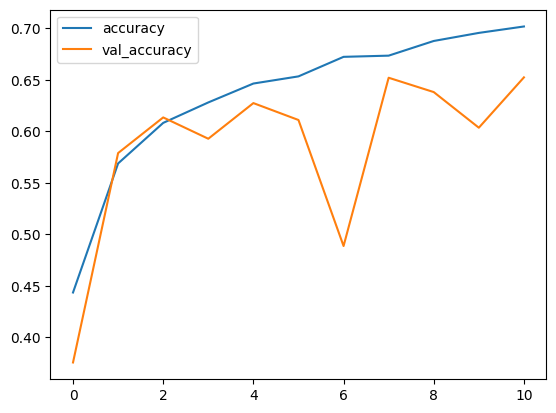

In [25]:
# Visualize results (both accuracy and loss)

import pandas as pd
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot()

In [ ]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.18.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
